European ATM CAll & Put Prices with correlation value -0.30, Q5
European Call Price under Heston:  3.4132849678726997
European Put Price under Heston:  2.4021661807284813
European Options Delta & Gamma, Q5-Q7
European Call Delta (Δ): 0.5979
European Put Delta (Δ): -0.4011
European Call Gamma (Γ): 0.054267
European Put Gamma (Γ): 0.054267


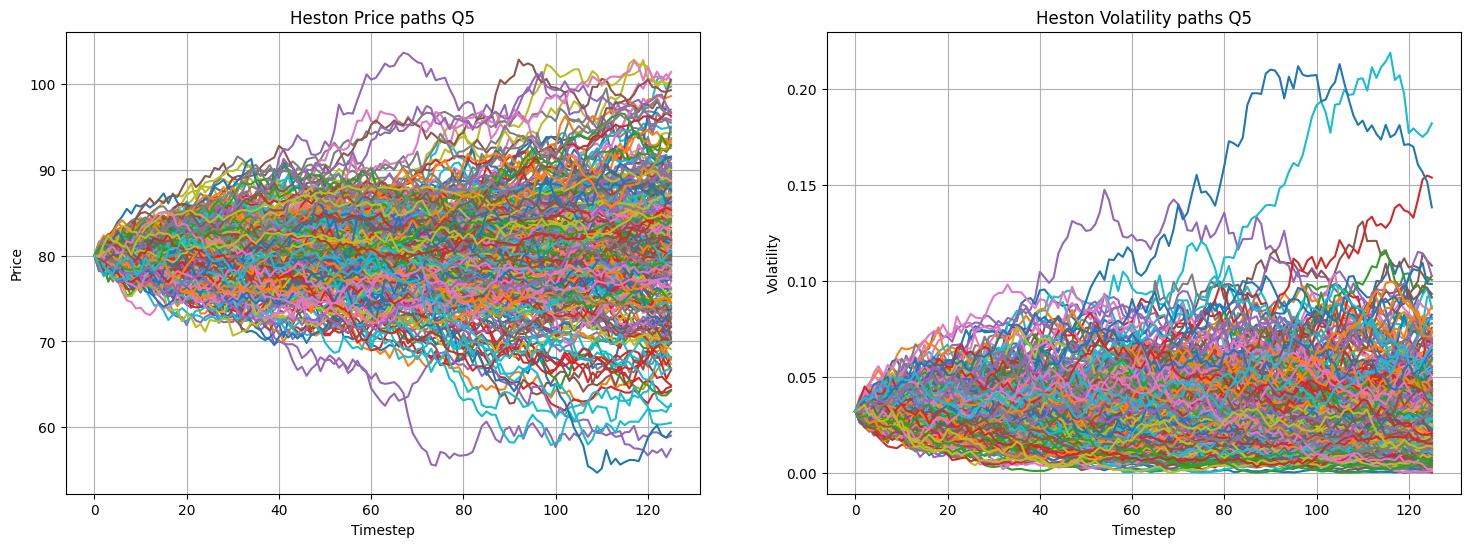

In [ ]:
# Q5 & Q7
import matplotlib.pyplot as plt
import numpy as np

# Function to simulate variance paths using Heston SDE
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt +
                          np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

# Function to simulate price paths under Heston model
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M + 1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t - 1]) * dt +
                                 np.sqrt(v[t - 1]) * ran[row] * sdt)
    return S

# Function to generate correlated random numbers
def random_number_gen(M, I):
    return np.random.standard_normal((2, M + 1, I))

# ------------------ Parameters ------------------
v0 = 0.032          # Initial variance
kappa_v = 1.85      # Mean reversion speed
sigma_v = 0.35      # Vol of vol
theta_v = 0.045     # Long run variance
rho = -0.30         # Correlation between price and variance

S0 = 80             # Initial stock price
r = 0.055           # Risk-free rate
M0 = 500            # Time steps per year
T = 0.25            # Time to maturity (in years)
M = int(M0 * T)     # Total time steps
I = 10000           # Number of simulations
dt = T / M          # Time increment

# Generate correlated random numbers
rand = random_number_gen(M, I)

# Covariance matrix and Cholesky decomposition
covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
cho_matrix = np.linalg.cholesky(covariance_matrix)

# Generate variance and stock price paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S = Heston_paths(S0, r, V, 0, cho_matrix)

# ------------------ Plot Paths ------------------
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.set_title("Heston Price paths Q5")
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Price")
    ax1.grid()

    ax2.plot(range(len(V)), V[:, :n])
    ax2.set_title("Heston Volatility paths Q5")
    ax2.set_xlabel("Timestep")
    ax2.set_ylabel("Volatility")
    ax2.grid()

plot_paths(300)

# ------------------ Option Pricing ------------------
def heston_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)
    return np.exp(-r * (T - t)) * np.mean(payoff)

def heston_put_mc(S, K, r, T, t):
    payoff = np.maximum(0, K - S[-1, :])
    return np.exp(-r * (T - t)) * np.mean(payoff)

K = S0  # ATM Strike

# Original Option Prices
call_original = heston_call_mc(S, K, r, T, 0)
put_original = heston_put_mc(S, K, r, T, 0)
print(f"European ATM CAll & Put Prices with correlation value -0.30, Q5")
print("European Call Price under Heston: ", call_original)
print("European Put Price under Heston: ", put_original)

# Q5-Q7------------------ Delta and Gamma ------------------
epsilon = 0.01 * S0  # Small change in underlying

# S0 + epsilon
S_plus = S0 + epsilon
V_plus = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S_paths_plus = Heston_paths(S_plus, r, V_plus, 0, cho_matrix)
call_plus = heston_call_mc(S_paths_plus, K, r, T, 0)
put_plus = heston_put_mc(S_paths_plus, K, r, T, 0)

# S0 - epsilon
S_minus = S0 - epsilon
V_minus = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S_paths_minus = Heston_paths(S_minus, r, V_minus, 0, cho_matrix)
call_minus = heston_call_mc(S_paths_minus, K, r, T, 0)
put_minus = heston_put_mc(S_paths_minus, K, r, T, 0)

# Delta: (Price up - Price down) / (2 * epsilon)
delta_call = (call_plus - call_minus) / (2 * epsilon)
delta_put = (put_plus - put_minus) / (2 * epsilon)

# Gamma: (Price up - 2 * Price original + Price down) / (epsilon^2)
gamma_call = (call_plus - 2 * call_original + call_minus) / (epsilon ** 2)
gamma_put = (put_plus - 2 * put_original + put_minus) / (epsilon ** 2)

# ------------------ Print Greeks ------------------
print(f"European Options Delta & Gamma, Q5-Q7")
print(f"European Call Delta (Δ): {delta_call:.4f}")
print(f"European Put Delta (Δ): {delta_put:.4f}")
print(f"European Call Gamma (Γ): {gamma_call:.6f}")
print(f"European Put Gamma (Γ): {gamma_put:.6f}")


European ATM CAll & Put Prices with correlation value -0.70, Q6
European Call Price under Heston:  3.5169857162871456
European Put Price under Heston:  2.3656911253307293
European Options Delta & Gamma, Q6-Q7
European Call Delta (Δ): 0.6321
European Put Delta (Δ): -0.3686
European Call Gamma (Γ): 0.051198
European Put Gamma (Γ): 0.051198


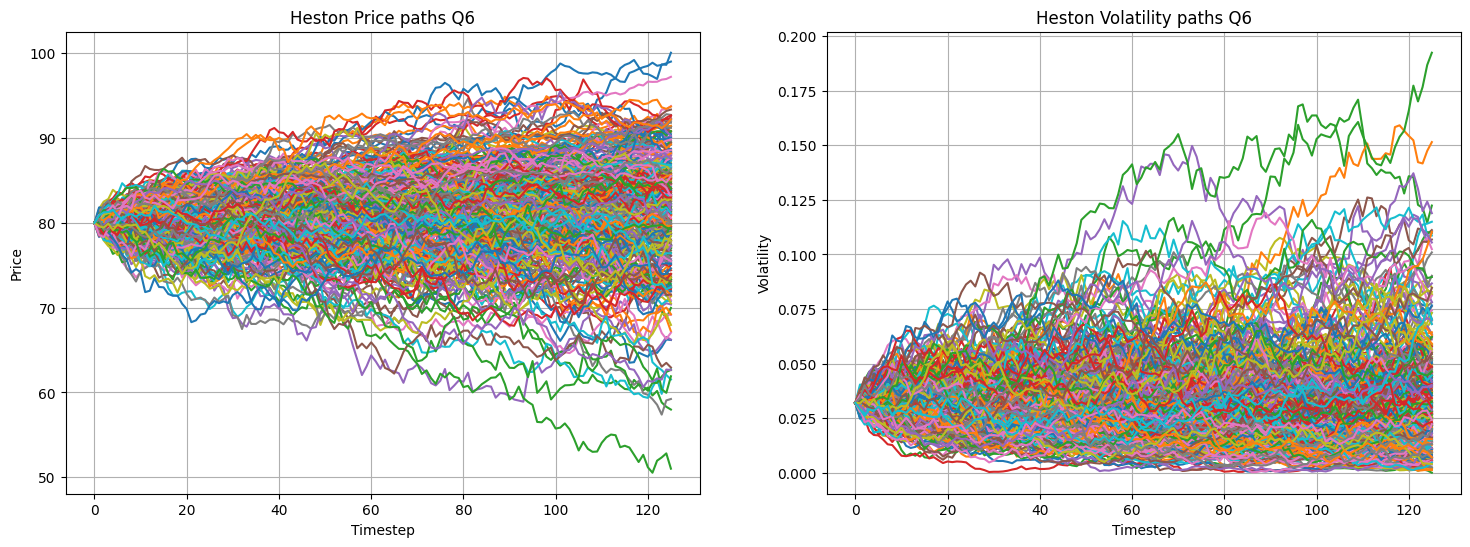

In [ ]:
# Q6 &Q7
import matplotlib.pyplot as plt
import numpy as np

# Function to simulate variance paths using Heston SDE
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt +
                          np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

# Function to simulate price paths under Heston model
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M + 1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t - 1]) * dt +
                                 np.sqrt(v[t - 1]) * ran[row] * sdt)
    return S

# Function to generate correlated random numbers
def random_number_gen(M, I):
    return np.random.standard_normal((2, M + 1, I))

# ------------------ Parameters ------------------
v0 = 0.032          # Initial variance
kappa_v = 1.85      # Mean reversion speed
sigma_v = 0.35      # Vol of vol
theta_v = 0.045     # Long run variance
rho = -0.70         # Correlation between price and variance

S0 = 80             # Initial stock price
r = 0.055           # Risk-free rate
M0 = 500            # Time steps per year
T = 0.25            # Time to maturity (in years)
M = int(M0 * T)     # Total time steps
I = 10000           # Number of simulations
dt = T / M          # Time increment

# Generate correlated random numbers
rand = random_number_gen(M, I)

# Covariance matrix and Cholesky decomposition
covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
cho_matrix = np.linalg.cholesky(covariance_matrix)

# Generate variance and stock price paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S = Heston_paths(S0, r, V, 0, cho_matrix)

# ------------------ Plot Paths ------------------
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.set_title("Heston Price paths Q6")
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Price")
    ax1.grid()

    ax2.plot(range(len(V)), V[:, :n])
    ax2.set_title("Heston Volatility paths Q6")
    ax2.set_xlabel("Timestep")
    ax2.set_ylabel("Volatility")
    ax2.grid()

plot_paths(300)

# ------------------ Option Pricing ------------------
def heston_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)
    return np.exp(-r * (T - t)) * np.mean(payoff)

def heston_put_mc(S, K, r, T, t):
    payoff = np.maximum(0, K - S[-1, :])
    return np.exp(-r * (T - t)) * np.mean(payoff)

K = S0  # ATM Strike

# Original Option Prices
call_original = heston_call_mc(S, K, r, T, 0)
put_original = heston_put_mc(S, K, r, T, 0)
print(f"European ATM CAll & Put Prices with correlation value -0.70, Q6")
print("European Call Price under Heston: ", call_original)
print("European Put Price under Heston: ", put_original)

# ------------------ Delta and Gamma ------------------
epsilon = 0.01 * S0  # Small change in underlying

# S0 + epsilon
S_plus = S0 + epsilon
V_plus = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S_paths_plus = Heston_paths(S_plus, r, V_plus, 0, cho_matrix)
call_plus = heston_call_mc(S_paths_plus, K, r, T, 0)
put_plus = heston_put_mc(S_paths_plus, K, r, T, 0)

# S0 - epsilon
S_minus = S0 - epsilon
V_minus = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S_paths_minus = Heston_paths(S_minus, r, V_minus, 0, cho_matrix)
call_minus = heston_call_mc(S_paths_minus, K, r, T, 0)
put_minus = heston_put_mc(S_paths_minus, K, r, T, 0)

# Delta: (Price up - Price down) / (2 * epsilon)
delta_call = (call_plus - call_minus) / (2 * epsilon)
delta_put = (put_plus - put_minus) / (2 * epsilon)

# Gamma: (Price up - 2 * Price original + Price down) / (epsilon^2)
gamma_call = (call_plus - 2 * call_original + call_minus) / (epsilon ** 2)
gamma_put = (put_plus - 2 * put_original + put_minus) / (epsilon ** 2)

# ------------------ Print Greeks ------------------
print(f"European Options Delta & Gamma, Q6-Q7")
print(f"European Call Delta (Δ): {delta_call:.4f}")
print(f"European Put Delta (Δ): {delta_put:.4f}")
print(f"European Call Gamma (Γ): {gamma_call:.6f}")
print(f"European Put Gamma (Γ): {gamma_put:.6f}")


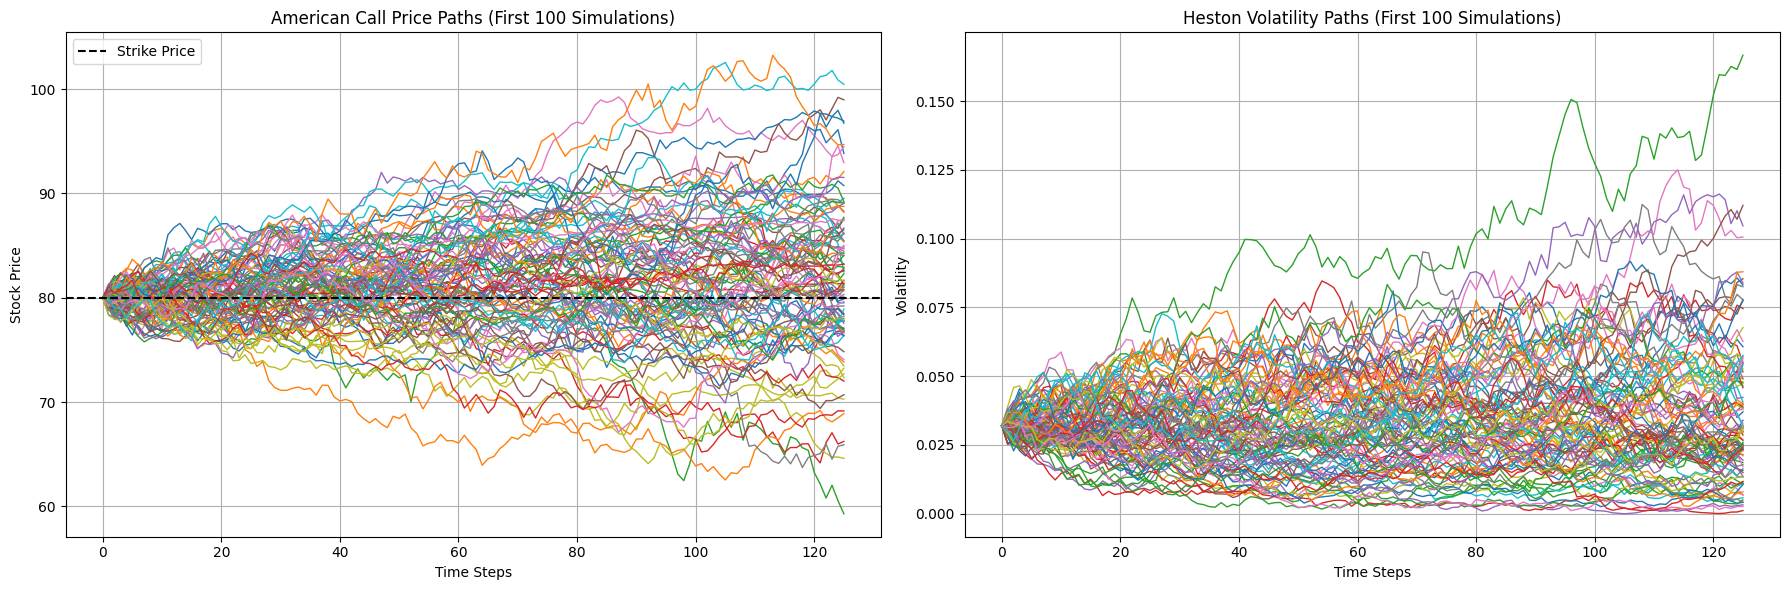


American ATM Call Price (LSM): 3.5260
American Call Delta (Δ): 0.5991
American Call Gamma (Γ): 0.035944


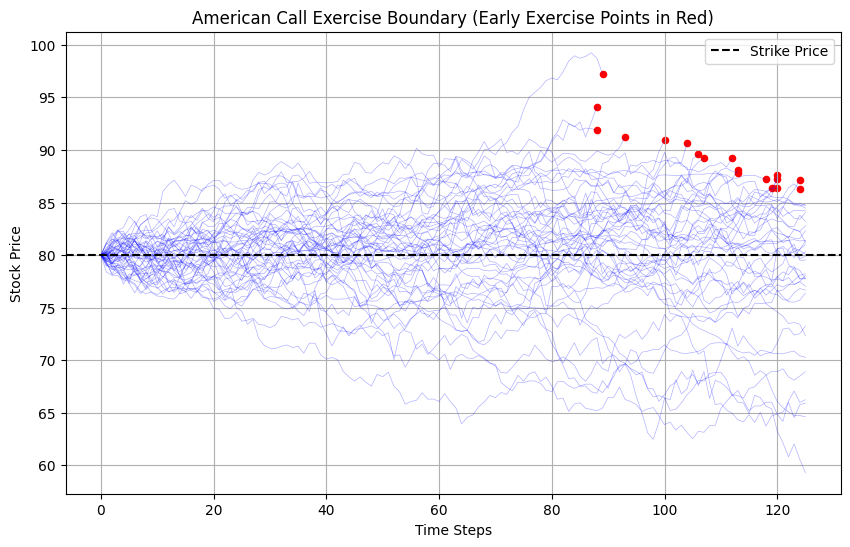

In [ ]:
# Q13
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.laguerre import lagval

# ------------------ Heston Model Functions ------------------
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt +
                          np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M + 1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t - 1]) * dt +
                                 np.sqrt(v[t - 1]) * ran[row] * sdt)
    return S

def random_number_gen(M, I):
    return np.random.standard_normal((2, M + 1, I))

# ------------------ Parameters ------------------
v0 = 0.032          # Initial variance
kappa_v = 1.85      # Mean reversion speed
sigma_v = 0.35      # Vol of vol
theta_v = 0.045     # Long run variance
rho = -0.30         # Correlation

S0 = 80             # Initial stock price
r = 0.055           # Risk-free rate
M0 = 500            # Time steps per year
T = 0.25            # Time to maturity (years)
M = int(M0 * T)     # Total time steps
I = 10000           # Number of simulations
dt = T / M          # Time increment
K = S0              # ATM strike

# Generate correlated random numbers
rand = random_number_gen(M, I)
cov_matrix = np.array([[1.0, rho], [rho, 1.0]])
cho_matrix = np.linalg.cholesky(cov_matrix)

# Generate paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S = Heston_paths(S0, r, V, 0, cho_matrix)

# ------------------ Plot American Call Paths ------------------
def plot_american_paths(S, V, n=100):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Price paths (highlighting early exercise points)
    ax1.plot(S[:, :n], lw=1.0)
    ax1.axhline(K, color='k', linestyle='--', label='Strike Price')
    ax1.set_title(f"American Call Price Paths (First {n} Simulations)")
    ax1.set_xlabel("Time Steps")
    ax1.set_ylabel("Stock Price")
    ax1.legend()
    ax1.grid(True)

    # Volatility paths
    ax2.plot(V[:, :n], lw=1.0)
    ax2.set_title(f"Heston Volatility Paths (First {n} Simulations)")
    ax2.set_xlabel("Time Steps")
    ax2.set_ylabel("Volatility")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_american_paths(S, V)  # Plot first 100 paths

# ------------------ American Call Pricing (LSM) ------------------
def american_call_lsm(S, K, r, T, M):
    dt = T / M
    df = np.exp(-r * dt)
    CF = np.maximum(S[-1] - K, 0)  # Final payoff

    # Track exercise boundaries
    exercise_times = np.full(I, M)  # Default: exercise at maturity

    for t in range(M - 1, 0, -1):
        in_the_money = S[t] > K
        X = S[t, in_the_money]
        Y = CF[in_the_money] * df

        if len(X) > 0:
            # Regression basis (Laguerre polynomials)
            X_scaled = np.exp(-X / (2 * K))
            L = np.column_stack([lagval(X_scaled, [1]*1),
                                lagval(X_scaled, [0, 1]),
                                lagval(X_scaled, [0, 0, 1])])
            coeff = np.linalg.lstsq(L, Y, rcond=None)[0]
            continuation = L @ coeff

            # Exercise decision
            exercise = X - K
            exercise_now = exercise > continuation
            CF[in_the_money] = np.where(exercise_now, exercise, CF[in_the_money] * df)
            exercise_times[in_the_money] = np.where(exercise_now, t, exercise_times[in_the_money])

    return np.mean(CF) * df, exercise_times

price, exercise_times = american_call_lsm(S, K, r, T, M)
print(f"\nAmerican ATM Call Price (LSM): {price:.4f}")

# ------------------ Greeks Calculation ------------------
epsilon = 0.01 * S0

# S0 + epsilon
S_plus = S0 + epsilon
V_plus = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S_paths_plus = Heston_paths(S_plus, r, V_plus, 0, cho_matrix)
call_plus, _ = american_call_lsm(S_paths_plus, K, r, T, M)

# S0 - epsilon
S_minus = S0 - epsilon
V_minus = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)
S_paths_minus = Heston_paths(S_minus, r, V_minus, 0, cho_matrix)
call_minus, _ = american_call_lsm(S_paths_minus, K, r, T, M)

# Delta and Gamma
delta = (call_plus - call_minus) / (2 * epsilon)
gamma = (call_plus - 2 * price + call_minus) / (epsilon ** 2)

print(f"American Call Delta (Δ): {delta:.4f}")
print(f"American Call Gamma (Γ): {gamma:.6f}")

# ------------------ Exercise Boundary Plot ------------------
def plot_exercise_boundary(S, exercise_times):
    plt.figure(figsize=(10, 6))

    # Plot paths with exercise points
    for i in range(min(50, I)):  # Plot first 50 paths
        ex_time = exercise_times[i]
        plt.plot(S[:ex_time+1, i], 'b-', lw=0.5, alpha=0.3)
        if ex_time < M:
            plt.scatter(ex_time, S[ex_time, i], color='red', s=20)

    plt.axhline(K, color='k', linestyle='--', label='Strike Price')
    plt.title("American Call Exercise Boundary (Early Exercise Points in Red)")
    plt.xlabel("Time Steps")
    plt.ylabel("Stock Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_exercise_boundary(S, exercise_times)

Start with as Team Member B - Q 8,9,10 and 15.


--- Question 8: Merton Model (lambda = 0.75) ---
ATM European Call Price: $8.29
ATM European Put Price:  $7.25
----------------------------------------------------

--- Question 9: Merton Model (lambda = 0.25) ---
ATM European Call Price: $6.86
ATM European Put Price:  $5.75
----------------------------------------------------

--- Question 10: Delta and Gamma Calculations ---
For Q8 (lambda=0.75):
  ATM Call: Delta = 0.6610, Gamma = 0.0014
  ATM Put:  Delta = -0.3903, Gamma = -0.0814
For Q9 (lambda=0.25):
  ATM Call: Delta = 0.5961, Gamma = 0.0527
  ATM Put:  Delta = -0.4157, Gamma = -0.0836

--- Question 15: Merton Down-and-In Put (lambda = 0.75, K=65.0, H=65.0) ---
Down-and-In Put Price: $2.78


--- Summary Table: Option Prices (Q8 & Q9) ---
| Question | Lambda | Option Type | Price ($) |
|---------------------------------------------|
| 8        | 0.75   | ATM Call    | 8.29      |
| 8        | 0.75   | ATM Put     | 7.25      |
| 9        | 0.25   | ATM Call    | 6.86      |
| 9 

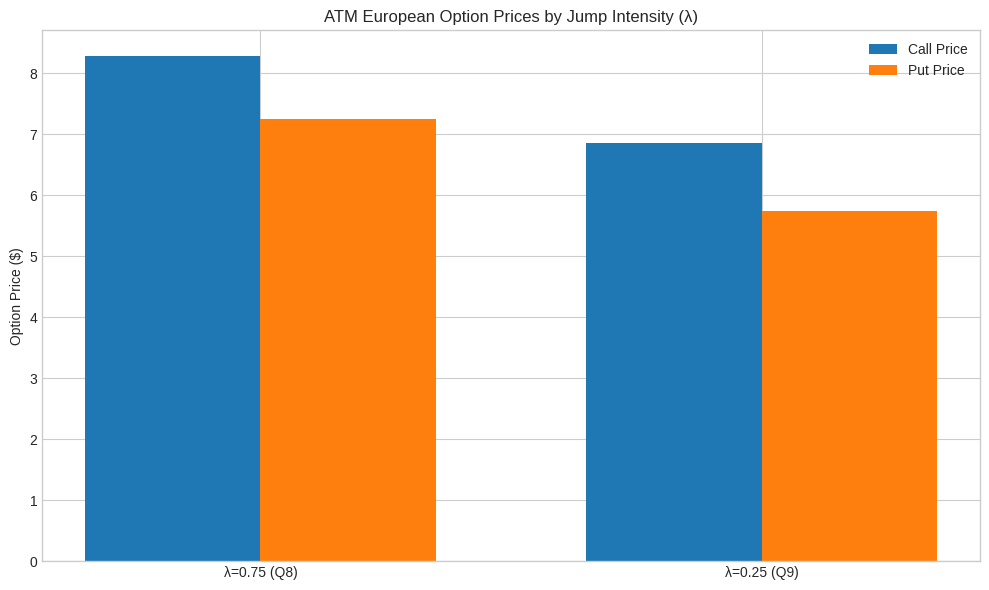

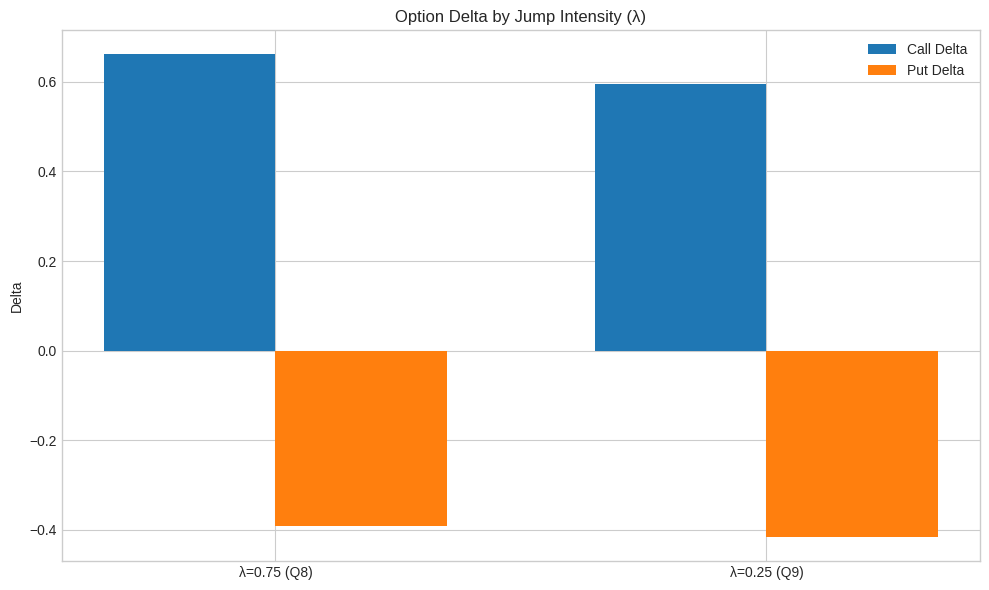

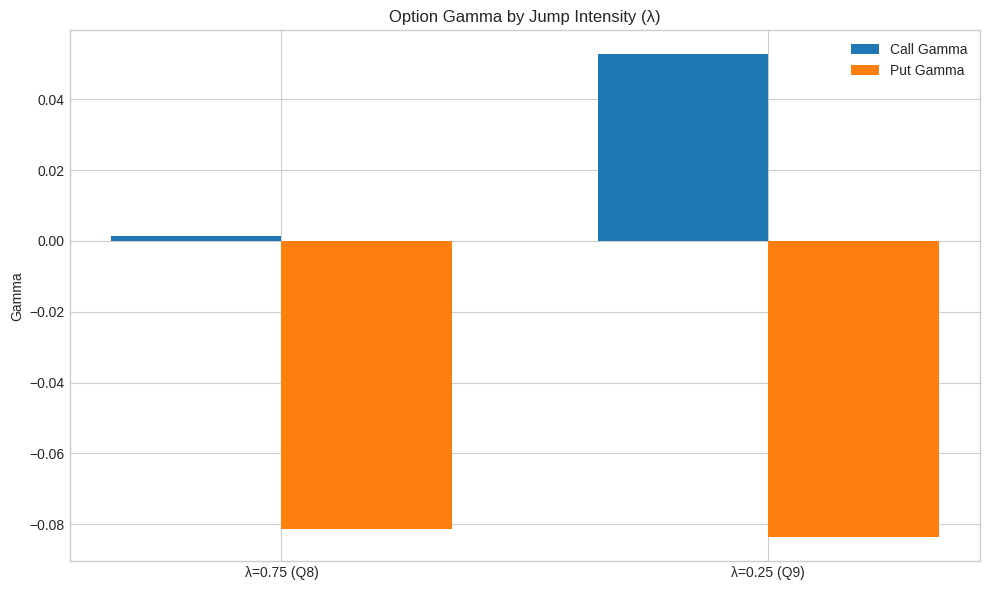

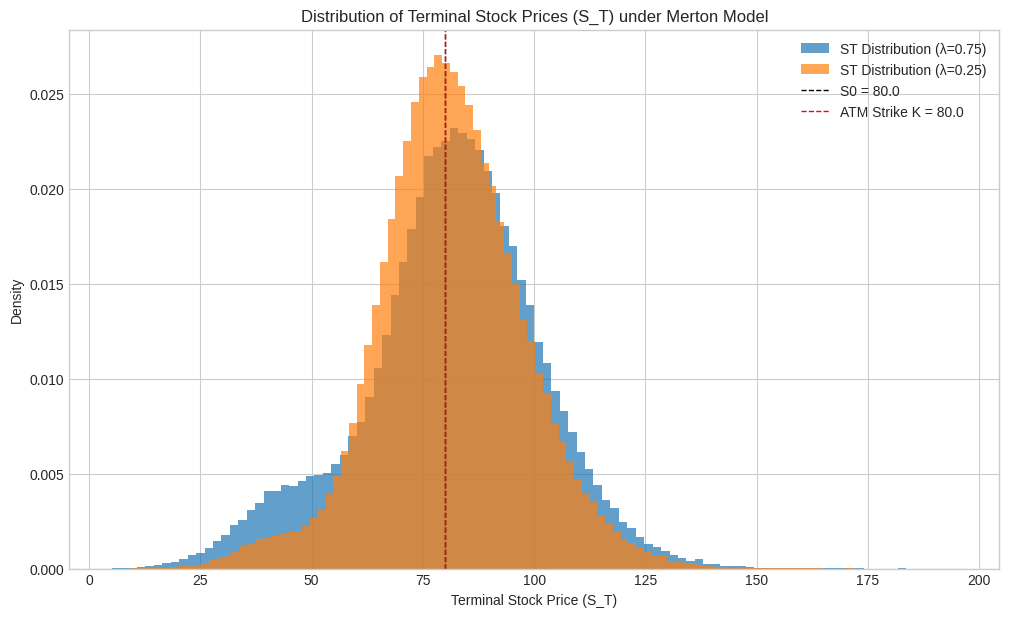

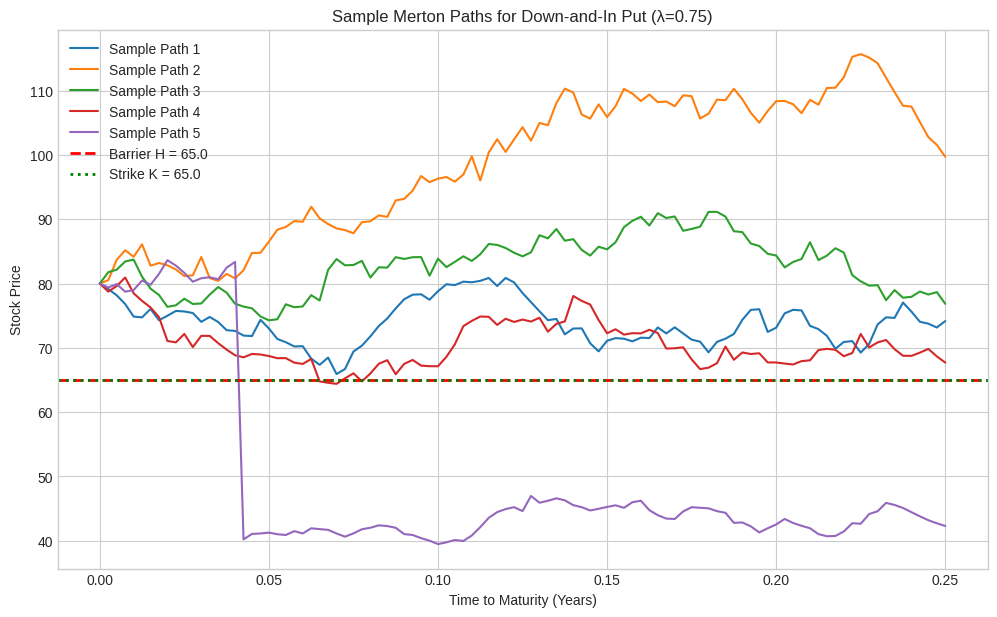

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set a seed for reproducibility
np.random.seed(42)

S0 = 80.0       # Initial stock price
r = 0.055       # Risk-free interest rate
sigma = 0.35    # Volatility of the continuous part
T = 0.25        # Time to maturity

# --- Merton Model Specific Parameters  ---
mu_j = -0.5
delta_j = 0.22

# --- Monte Carlo Parameters ---
num_simulations = 200000  #  Simulations
num_steps = 100           # Number of time steps for path-dependent options


k_jump_adj = np.exp(mu_j + 0.5 * delta_j**2) - 1

# --- Function to Price European Options using Merton Model ---
def merton_european_option_mc(S0, K, T, r, sigma, lambda_val, mu_j, delta_j, k_adj,
                              option_type='call', num_simulations=num_simulations,
                              return_st_values=False):

    ST_array = np.zeros(num_simulations)

    for i in range(num_simulations):
        num_jumps = np.random.poisson(lambda_val * T)
        if num_jumps > 0:
            sum_of_log_jumps = np.sum(np.random.normal(mu_j, delta_j, num_jumps))
        else:
            sum_of_log_jumps = 0.0
        Z = np.random.standard_normal()
        drift_term = (r - lambda_val * k_adj - 0.5 * sigma**2) * T
        diffusion_term = sigma * np.sqrt(T) * Z
        ST = S0 * np.exp(drift_term + diffusion_term + sum_of_log_jumps)
        ST_array[i] = ST

    if option_type == 'call':
        payoffs = np.maximum(ST_array - K, 0)
    elif option_type == 'put':
        payoffs = np.maximum(K - ST_array, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    option_price = np.mean(payoffs) * np.exp(-r * T)

    if return_st_values:
        return option_price, ST_array
    else:
        return option_price

# --- Function to Calculate Greeks Numerically ---
def calculate_greeks_merton(S0_val, K, T, r, sigma, lambda_val, mu_j, delta_j, k_adj,
                            option_type='call', num_simulations=num_simulations,
                            dS_ratio=0.01):
    dS = S0_val * dS_ratio
    price_S0 = merton_european_option_mc(S0_val, K, T, r, sigma, lambda_val, mu_j, delta_j, k_adj,
                                        option_type, num_simulations)
    price_S0_plus_dS = merton_european_option_mc(S0_val + dS, K, T, r, sigma, lambda_val, mu_j, delta_j, k_adj,
                                               option_type, num_simulations)
    price_S0_minus_dS = merton_european_option_mc(S0_val - dS, K, T, r, sigma, lambda_val, mu_j, delta_j, k_adj,
                                                option_type, num_simulations)
    delta = (price_S0_plus_dS - price_S0_minus_dS) / (2 * dS)
    gamma = (price_S0_plus_dS - 2 * price_S0 + price_S0_minus_dS) / (dS**2)
    return delta, gamma, price_S0

# --- Function to Price Down-and-In Put Option using Merton Model (Q15) ---
def merton_down_and_in_put_mc(S0, K_pdi, T, r, sigma, lambda_val, mu_j, delta_j, k_adj,
                               barrier_H, num_simulations=num_simulations, num_steps=num_steps,
                               return_sample_paths=False, num_sample_paths_to_return=3):
    dt = T / num_steps
    payoffs = np.zeros(num_simulations)
    sample_paths_list = []

    for i in range(num_simulations):
        current_S = S0
        barrier_breached = False
        path_simulation = np.zeros(num_steps + 1)
        path_simulation[0] = S0

        for step_idx in range(num_steps):
            num_jumps_dt = np.random.poisson(lambda_val * dt)
            if num_jumps_dt > 0:
                sum_of_log_jumps_dt = np.sum(np.random.normal(mu_j, delta_j, num_jumps_dt))
            else:
                sum_of_log_jumps_dt = 0.0
            Z_dt = np.random.standard_normal()
            drift_dt = (r - lambda_val * k_adj - 0.5 * sigma**2) * dt
            diffusion_dt = sigma * np.sqrt(dt) * Z_dt
            current_S = current_S * np.exp(drift_dt + diffusion_dt + sum_of_log_jumps_dt)
            path_simulation[step_idx + 1] = current_S

            if current_S <= barrier_H:
                barrier_breached = True

        if barrier_breached:
            payoffs[i] = np.maximum(K_pdi - current_S, 0)
        else:
            payoffs[i] = 0.0

        if return_sample_paths and i < num_sample_paths_to_return :
             sample_paths_list.append(path_simulation)

    pdi_price = np.mean(payoffs) * np.exp(-r * T)

    if return_sample_paths:
        return pdi_price, sample_paths_list
    else:
        return pdi_price

# --- Main Execution & Results Presentation ---
K_atm = S0
results_q8_q9_options = []
results_q10_greeks = []
st_values_storage = {}

# Question 8: Merton Model, lambda = 0.75
lambda_q8 = 0.75
print(f"\n--- Question 8: Merton Model (lambda = {lambda_q8}) ---")
q8_call_price, q8_st_values = merton_european_option_mc(S0, K_atm, T, r, sigma, lambda_q8, mu_j, delta_j, k_jump_adj, 'call', return_st_values=True)
q8_put_price = merton_european_option_mc(S0, K_atm, T, r, sigma, lambda_q8, mu_j, delta_j, k_jump_adj, 'put')
st_values_storage[lambda_q8] = q8_st_values
results_q8_q9_options.append({
    "Question": "8", "Lambda": lambda_q8, "Option Type": "ATM Call", "Price": round(q8_call_price, 2)
})
results_q8_q9_options.append({
    "Question": "8", "Lambda": lambda_q8, "Option Type": "ATM Put", "Price": round(q8_put_price, 2)
})
print(f"ATM European Call Price: ${q8_call_price:.2f}")
print(f"ATM European Put Price:  ${q8_put_price:.2f}")
print("----------------------------------------------------")

# Question 9: Merton Model, lambda = 0.25
lambda_q9 = 0.25
print(f"\n--- Question 9: Merton Model (lambda = {lambda_q9}) ---")
q9_call_price, q9_st_values = merton_european_option_mc(S0, K_atm, T, r, sigma, lambda_q9, mu_j, delta_j, k_jump_adj, 'call', return_st_values=True)
q9_put_price = merton_european_option_mc(S0, K_atm, T, r, sigma, lambda_q9, mu_j, delta_j, k_jump_adj, 'put')
st_values_storage[lambda_q9] = q9_st_values
results_q8_q9_options.append({
    "Question": "9", "Lambda": lambda_q9, "Option Type": "ATM Call", "Price": round(q9_call_price, 2)
})
results_q8_q9_options.append({
    "Question": "9", "Lambda": lambda_q9, "Option Type": "ATM Put", "Price": round(q9_put_price, 2)
})
print(f"ATM European Call Price: ${q9_call_price:.2f}")
print(f"ATM European Put Price:  ${q9_put_price:.2f}")
print("----------------------------------------------------")

# Question 10: Delta and Gamma for Q8 & Q9 options
print("\n--- Question 10: Delta and Gamma Calculations ---")

# For Q8 options (lambda = 0.75)
q8_call_delta, q8_call_gamma, _ = calculate_greeks_merton(S0, K_atm, T, r, sigma, lambda_q8, mu_j, delta_j, k_jump_adj, 'call')
q8_put_delta, q8_put_gamma, _ = calculate_greeks_merton(S0, K_atm, T, r, sigma, lambda_q8, mu_j, delta_j, k_jump_adj, 'put')
results_q10_greeks.append({
    "Ref Question": "8", "Lambda": lambda_q8, "Option Type": "ATM Call", "Delta": q8_call_delta, "Gamma": q8_call_gamma
})
results_q10_greeks.append({
    "Ref Question": "8", "Lambda": lambda_q8, "Option Type": "ATM Put", "Delta": q8_put_delta, "Gamma": q8_put_gamma
})
print(f"For Q8 (lambda={lambda_q8}):")
print(f"  ATM Call: Delta = {q8_call_delta:.4f}, Gamma = {q8_call_gamma:.4f}")
print(f"  ATM Put:  Delta = {q8_put_delta:.4f}, Gamma = {q8_put_gamma:.4f}")

# For Q9 options (lambda = 0.25)
q9_call_delta, q9_call_gamma, _ = calculate_greeks_merton(S0, K_atm, T, r, sigma, lambda_q9, mu_j, delta_j, k_jump_adj, 'call')
q9_put_delta, q9_put_gamma, _ = calculate_greeks_merton(S0, K_atm, T, r, sigma, lambda_q9, mu_j, delta_j, k_jump_adj, 'put')
results_q10_greeks.append({
    "Ref Question": "9", "Lambda": lambda_q9, "Option Type": "ATM Call", "Delta": q9_call_delta, "Gamma": q9_call_gamma
})
results_q10_greeks.append({
    "Ref Question": "9", "Lambda": lambda_q9, "Option Type": "ATM Put", "Delta": q9_put_delta, "Gamma": q9_put_gamma
})
print(f"For Q9 (lambda={lambda_q9}):")
print(f"  ATM Call: Delta = {q9_call_delta:.4f}, Gamma = {q9_call_gamma:.4f}")
print(f"  ATM Put:  Delta = {q9_put_delta:.4f}, Gamma = {q9_put_gamma:.4f}")

# Question 15: Merton Model, Down-and-In Put Option
K_pdi_q15 = 65.0
barrier_H_q15 = 65.0
print(f"\n--- Question 15: Merton Down-and-In Put (lambda = {lambda_q8}, K={K_pdi_q15}, H={barrier_H_q15}) ---")
q15_pdi_price, q15_sample_paths = merton_down_and_in_put_mc(
    S0, K_pdi_q15, T, r, sigma, lambda_q8, mu_j, delta_j, k_jump_adj,
    barrier_H_q15, num_simulations, num_steps, return_sample_paths=True, num_sample_paths_to_return=5
)
print(f"Down-and-In Put Price: ${q15_pdi_price:.2f}")

# --- Tabulated Summary of Option Prices (Q8 & Q9) ---
print("\n\n--- Summary Table: Option Prices (Q8 & Q9) ---")
header_options = "| Question | Lambda | Option Type | Price ($) |"
print(header_options)
print("|" + "-"*(len(header_options)-2) + "|")
for res in results_q8_q9_options:
    print(f"| {res['Question']:<8} | {res['Lambda']:<6.2f} | {res['Option Type']:<11} | {res['Price']:<9.2f} |") # Adjusted Lambda format

# --- Tabulated Summary of Greeks (Q10) ---
print("\n\n--- Summary Table: Greeks (Q10) ---")
header_greeks = "| Ref Q | Lambda | Option Type |   Delta   |   Gamma   |"
print(header_greeks)
print("|" + "-"*(len(header_greeks)-2) + "|")
for res in results_q10_greeks:
    print(f"| {res['Ref Question']:<5} | {res['Lambda']:<6.2f} | {res['Option Type']:<11} | {res['Delta']:<9.4f} | {res['Gamma']:<9.4f} |") # Adjusted Lambda format

# --- Summary for Q15 PDI Option ---
print("\n\n--- Summary: Barrier Option Price (Q15) ---")
print(f"Question 15: Merton Down-and-In Put (lambda={lambda_q8}, K={K_pdi_q15}, H={barrier_H_q15})")
print(f"  Price: ${round(q15_pdi_price, 2):.2f}")



plt.style.use('seaborn-v0_8-whitegrid')


labels = ['λ=0.75 (Q8)', 'λ=0.25 (Q9)']
call_prices_plot = [q8_call_price, q9_call_price]
put_prices_plot = [q8_put_price, q9_put_price]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, call_prices_plot, width, label='Call Price')
rects2 = ax.bar(x + width/2, put_prices_plot, width, label='Put Price')

ax.set_ylabel('Option Price ($)')
ax.set_title('ATM European Option Prices by Jump Intensity (λ)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
fig.tight_layout()
plt.show()


delta_call_plot = [results_q10_greeks[0]['Delta'], results_q10_greeks[2]['Delta']]
delta_put_plot = [results_q10_greeks[1]['Delta'], results_q10_greeks[3]['Delta']]

fig, ax = plt.subplots(figsize=(10, 6))
rects1_delta = ax.bar(x - width/2, delta_call_plot, width, label='Call Delta')
rects2_delta = ax.bar(x + width/2, delta_put_plot, width, label='Put Delta')

ax.set_ylabel('Delta')
ax.set_title('Option Delta by Jump Intensity (λ)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
fig.tight_layout()
plt.show()


gamma_call_plot = [results_q10_greeks[0]['Gamma'], results_q10_greeks[2]['Gamma']]
gamma_put_plot = [results_q10_greeks[1]['Gamma'], results_q10_greeks[3]['Gamma']]

fig, ax = plt.subplots(figsize=(10, 6))
rects1_gamma = ax.bar(x - width/2, gamma_call_plot, width, label='Call Gamma')
rects2_gamma = ax.bar(x + width/2, gamma_put_plot, width, label='Put Gamma')

ax.set_ylabel('Gamma')
ax.set_title('Option Gamma by Jump Intensity (λ)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
fig.tight_layout()
plt.show()


plt.figure(figsize=(12, 7))
plt.hist(st_values_storage[lambda_q8], bins=100, alpha=0.7, label=f'ST Distribution (λ={lambda_q8})', density=True)
plt.hist(st_values_storage[lambda_q9], bins=100, alpha=0.7, label=f'ST Distribution (λ={lambda_q9})', density=True)
plt.title('Distribution of Terminal Stock Prices (S_T) under Merton Model')
plt.xlabel('Terminal Stock Price (S_T)')
plt.ylabel('Density')
plt.axvline(S0, color='black', linestyle='dashed', linewidth=1, label=f'S0 = {S0}')
plt.axvline(K_atm, color='red', linestyle='dashed', linewidth=1, label=f'ATM Strike K = {K_atm}')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 7))
time_axis = np.linspace(0, T, num_steps + 1)
for i, path in enumerate(q15_sample_paths):
    plt.plot(time_axis, path, lw=1.5, label=f'Sample Path {i+1}')

plt.axhline(barrier_H_q15, color='red', ls='--', lw=2, label=f'Barrier H = {barrier_H_q15}')
plt.axhline(K_pdi_q15, color='green', ls=':', lw=2, label=f'Strike K = {K_pdi_q15}')
plt.title(f'Sample Merton Paths for Down-and-In Put (λ={lambda_q8})')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Stock Price')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

**Team Member C - Q12 and Q14**

In [1]:
import numpy as np
from scipy.stats import norm

# Heston Model Simulation
def heston_call_price(S0, K, T, r, v0, kappa, theta, sigma, rho, num_simulations=100000):
    dt = T / 252
    ST = np.zeros(num_simulations)
    v = v0 * np.ones(num_simulations)

    for t in range(int(T * 252)):
        Z1 = np.random.standard_normal(num_simulations)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(num_simulations)

        v = np.maximum(v + kappa * (theta - v) * dt + sigma * np.sqrt(v * dt) * Z2, 0)
        ST = ST * np.exp((r - 0.5 * v) * dt + np.sqrt(v * dt) * Z1)

    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

# Strikes and moneyness
moneyness = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
strikes = [80 / m for m in moneyness]

# Heston prices
heston_prices = [heston_call_price(S0=80, K=K, T=0.25, r=0.055, v0=0.032, kappa=1.85, theta=0.045, sigma=0.35, rho=-0.30)
                 for K in strikes]

In [2]:
# Merton Model Simulation
def merton_call_price(S0, K, T, r, sigma, lambda_val, mu_j, delta_j, num_simulations=100000):
    k = np.exp(mu_j + 0.5 * delta_j**2) - 1
    ST = np.zeros(num_simulations)

    for i in range(num_simulations):
        num_jumps = np.random.poisson(lambda_val * T)
        jumps = np.sum(np.random.normal(mu_j, delta_j, num_jumps)) if num_jumps > 0 else 0
        Z = np.random.standard_normal()
        drift = (r - lambda_val * k - 0.5 * sigma**2) * T
        diffusion = sigma * np.sqrt(T) * Z
        ST[i] = S0 * np.exp(drift + diffusion + jumps)

    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

# Merton prices
merton_prices = [merton_call_price(S0=80, K=K, T=0.25, r=0.055, sigma=0.35, lambda_val=0.75, mu_j=-0.5, delta_j=0.22)
                 for K in strikes]

In [3]:
import numpy as np

def heston_up_in_call(S0, K, H, T, r, v0, kappa, theta, sigma_v, rho, num_sims=100000, num_steps=63):
    """
    Prices both standard European call and up-and-in call options
    using Heston model via Monte Carlo simulation
    """
    # Initialize arrays
    standard_call_payoffs = np.zeros(num_sims)
    up_in_call_payoffs = np.zeros(num_sims)

    dt = T / num_steps

    for i in range(num_sims):
        # Initialize paths
        S = np.zeros(num_steps + 1)
        v = np.zeros(num_steps + 1)
        S[0] = S0
        v[0] = v0
        max_price = S0

        # Correlated Brownian motions
        Z1 = np.random.normal(0, 1, num_steps)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.normal(0, 1, num_steps)

        for t in range(1, num_steps + 1):
            # Ensure variance remains positive
            v_prev = max(v[t-1], 1e-4)

            # Update variance
            v[t] = v_prev + kappa * (theta - v_prev) * dt + \
                   sigma_v * np.sqrt(v_prev * dt) * Z2[t-1]

            # Update stock price
            S[t] = S[t-1] * np.exp((r - 0.5 * v_prev) * dt + \
                   np.sqrt(v_prev * dt) * Z1[t-1])

            # Track maximum price
            max_price = max(max_price, S[t])

        # Calculate payoffs
        payoff = max(S[-1] - K, 0)
        standard_call_payoffs[i] = payoff

        if max_price >= H:
            up_in_call_payoffs[i] = payoff

    # Discount payoffs
    discount = np.exp(-r * T)
    standard_price = discount * np.mean(standard_call_payoffs)
    up_in_price = discount * np.mean(up_in_call_payoffs)

    # Calculate barrier hitting probability
    barrier_prob = np.mean(up_in_call_payoffs > 0)

    return standard_price, up_in_price, barrier_prob

# Run simulation
standard_call, up_in_call, barrier_prob = heston_up_in_call(
    S0=80, K=95, H=95, T=0.25, r=0.055, v0=0.032,
    kappa=1.85, theta=0.045, sigma_v=0.35, rho=-0.70
)

print(f"Standard European Call Price: ${standard_call:.4f}")
print(f"Up-and-In Call Price: ${up_in_call:.4f}")
print(f"Barrier Hitting Probability: {barrier_prob:.2%}")

Standard European Call Price: $0.0303
Up-and-In Call Price: $0.0303
Barrier Hitting Probability: 1.42%


**FootNote

Advantage for using AI:
Needing less time to collect information and to evaluate it for accuracy as compared to using
bibliographical research.**